#** Overview**
this project alims to build a machine learning model that can estimate house prices desed on various features such as location, number of rooms, and tax rates. we used the Boston Housing Dataset train our model.
#**project goal**
the main objective is to provide an accurate pricing tool for real estate stakeholders, helping them make data-driven decisions using the **Random Forest Regressor Algorithm**  
#**Work flow**
  1.**Data cleaining:** Handling missing values and exploring data patterns.
  2.**Deature scaling:** Normalizing data for better model performance.
  3.**Model training:** training and fine-tuning the random forest model.
  4.**Evaluation:**comparing actual Vs predicted prices using visual and statistical metrics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#1.Loud the dataset
#  professional note:ensure the file path is correct
data=pd.read_csv("/content/boston.csv")

In [3]:
#2.Check for data types,missing values,
#  and memory usage to ensure data cleanliness
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [4]:
#3.Exploratory data analysis(EDA)
#  GOAL:understand tha data distrbution
#  and check for anomalises
print("dataset overview")
print(data.describe())

dataset overview
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28

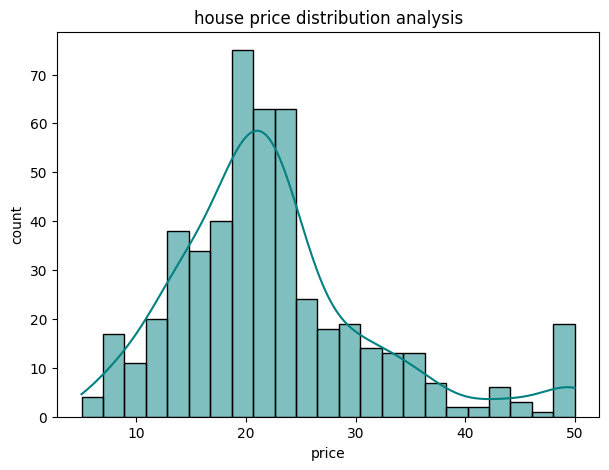

In [5]:
#4.Visualization the target variable (price)
#  usinge a histogram with KED to check for normality.
# Note:many regression models assume a normal distribution
#  for better performance.
plt.figure(figsize=(7,5))
sns.histplot(data['MEDV'],kde=True,color="teal")

# Adding descriptive labels for professional presentation
plt.title("house price distribution analysis")
plt.xlabel("price")
plt.ylabel("count")
plt.show();

# **Data Analysis Observation**
TargetVariable Distribution:
  the price(MEDV) followes a nearly  normal distribtion but with a slight positive skew.

outliers detection:
  there is a noticeable peak $50,000 ,which may indicate capped data or extreme outliers.

data readiness:
  the distribution suggests that the data might need scaling or log tranformation later for better model accuracy.

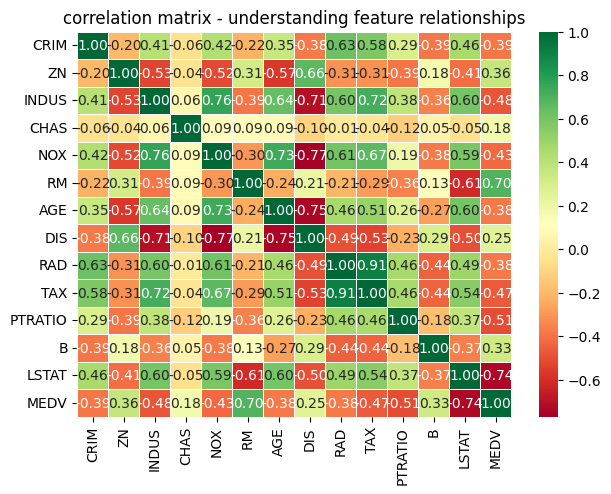

In [6]:
#5.Calculate the correlation matrix to find
#   relationships between varibles.
corr_matrix=data.corr()
# Set up the figure size for better readability.
plt.figure(figsize=(7,5))
# Creat heatmap using seaborn with professional formatting.
#annot=true:to show the numbers inside the squares.
#cmap="RdYlGn":Red for negative,Green for positive.
#fmt=".2f"keeo only two decimals.
sns.heatmap(corr_matrix,annot=True,cmap="RdYlGn", fmt=".2F",linewidths=0.5)
# Add a title to the heatmap
plt.title("correlation matrix - understanding feature relationships")
plt.show();


# **Corrolation Analysis Observations**
Afer analysis the heatmap, we can identify the most influential features on the house price(MEDV).
*Strong positive correlation*:
  RM(0.70) the numbers of rooms has a strong positive impact on the price. As rooms increase,price increases
*Strong nigative correlation*:
  LSTAT(-0.74):this is the strongest negative factor. High poverty percentage leads towv lower house price.
*multi-collinearity note*:
  features like RED and TAX have a very high correlation (0.91),which means they provide similar information.
*Target status*:
  As seen in the histogram, MEDV has some outliers at the 50 range that need handling.

In [7]:
#6.Removing outliers where MEDV is
#   exactly 50 (capped data)
data=data[data["MEDV"]<50]
# Resetting index after dropping rows
data=data.reset_index(drop=True)


In [8]:
#7.Separate features (x) and target variable (y)
x=data.drop(["MEDV"],axis=1)
y=data["MEDV"]

In [9]:
from sklearn.model_selection import train_test_split
#8.Splitting data info 80% training and 20% testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#9.Fit & transform on training data (learning the mean and std)
x_train_scaled=scaler.fit_transform(x_train)
# Only transform on tasting data (using the mean from training)
x_test_scaled=scaler.transform(x_test)


In [11]:
#10.Import all necessary libraries for the 6 algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.svm import SVR

In [12]:
#11.Define the 6 models in a dictionary
models={"Linear Regression":LinearRegression(),
        "Decision tree":DecisionTreeRegressor(random_state=42),
        "Random Forest":RandomForestRegressor(n_estimators=300,random_state=42),
        "KNN":KNeighborsRegressor(n_neighbors=5),
        "SVR":SVR(kernel="rbf"),
        "linear SVR":SVR(kernel="linear")
        }
# List to store results
results=[]
# Loop through the 6 models
for name,model in models.items():
  # Training
  model.fit(x_train_scaled,y_train)
  # Prediction
  preds=model.predict(x_test_scaled)
  # Evaluation
  r2=r2_score(y_test,preds)
  mae=mean_squared_error(y_test,preds)
  results.append({"model":name,
                  "Accuracy_R2":round(r2,4),
                  "MAE":round(mae,4)
                  })
  # Display the final comparison table
  comparison_df=pd.DataFrame(results).sort_values(by="Accuracy_R2",ascending=False)
  print("**final 6 models comparison**")
  print(comparison_df)


**final 6 models comparison**
               model  Accuracy_R2      MAE
0  Linear Regression        0.764  12.0559
**final 6 models comparison**
               model  Accuracy_R2      MAE
1      Decision tree       0.8165   9.3726
0  Linear Regression       0.7640  12.0559
**final 6 models comparison**
               model  Accuracy_R2      MAE
2      Random Forest       0.8799   6.1360
1      Decision tree       0.8165   9.3726
0  Linear Regression       0.7640  12.0559
**final 6 models comparison**
               model  Accuracy_R2      MAE
2      Random Forest       0.8799   6.1360
1      Decision tree       0.8165   9.3726
3                KNN       0.7752  11.4839
0  Linear Regression       0.7640  12.0559
**final 6 models comparison**
               model  Accuracy_R2      MAE
2      Random Forest       0.8799   6.1360
1      Decision tree       0.8165   9.3726
3                KNN       0.7752  11.4839
0  Linear Regression       0.7640  12.0559
4                SVR       0.6923

/tmp/ipython-input-2520854147.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x="model",y="Accuracy_R2",data=comparison_df,palette="viridis")


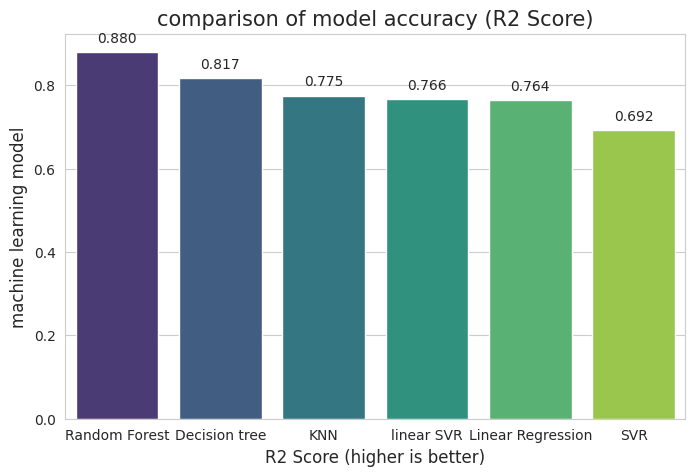

In [13]:
#12.Setting the style
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
# Cerat the bar chart for R2 score
ax=sns.barplot(x="model",y="Accuracy_R2",data=comparison_df,palette="viridis")
# Adding labels and title
plt.title("comparison of model accuracy (R2 Score)",fontsize=15)
plt.xlabel("R2 Score (higher is better)",fontsize=12)
plt.ylabel("machine learning model",fontsize=12)
# Adding the actual values on the bars
for i in ax.containers:
  ax.bar_label(i,fmt="%.3f",padding=5,fontsize=10)
plt.show()

# **Final model Evaluation**
*The winner*:
  random forest achieved the highest accuracy(88.0%).
*Error Analysis*:
  the MAE is 6.1,which means an average error of $6,100 .while it seems high, it is significantly better than Linear Regression (12.0).
*Context*:
  given that average house price are 22,500, error is acceptable for an inital model.
*Next step*:
  perform Hyperparameter tuning to further reduce this error.


In [14]:
from sklearn.model_selection import GridSearchCV
#12.Define the grid of parameters to search
param_grid={
    "n_estimators":[200,300,500],# Number of tree
    "max_depth":[None,10,20],# Maximum depth of the tree
    "min_samples_split":[2,5],# Min samples to split a node
    "max_features":[1.0,"sqrt"]#Number of features for best split
}
#Initialize GridSearchCV with the winning model (random forest)
grid_search=GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                         param_grid=param_grid,cv=5, #crros-validation folds
                         n_jobs=-1, #use all processors
                         scoring="r2", #Focus on R2 Score
                         verbose=2, # show process
                         )
# Start the tuning process (this might take minute)
grid_search.fit(x_train_scaled,y_train)
# Results
print("**result Summary**")
print(F"Best parameters:{grid_search.best_params_}")
print(F"best R2 score : {grid_search.best_score_:.4f}")
# use the best model to update your final model
best_rf_model=grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
**result Summary**
Best parameters:{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
best R2 score : 0.8697


# Step 2: Hyperparameter tuning results
*Process*:
 conducted a Grid search on randon rorest using 5-fold Cross - validation (180 total fits).
*Best parameters*:
  best with n_estimators:300, max_features:"sqrt",and min_samples_split:2.
*Final Accuracy*:
  the stable R2 Score is now 87.0%.
# Conclusion:
  this model is more robust and ready for real-world predictions than the initial version       

In [15]:
import joblib
#Saving the best model
joblib.dump(best_rf_model,"final_house_price_model_pk1")
#Saving th scaler
joblib.dump(scaler,"scaler_pk1")
print("model and scaler saved succesfully")

model and scaler saved succesfully


# Model Export & Deployment
*step*:
  exported the final optimized model using joblib
*purpose*: this allows us to use the model in prodiction (web\app) with out retraing  

In [20]:
#Loading the saved model and scaler
loaded_model=joblib.load("final_house_price_model_pk1")
loaded_scaler=joblib.load("scaler_pk1")
# New house data (Input your features here)
new_house_data=np.array([[0.00632,18.0,2.31,0,0.538,6.575,65.2,4.09,1,1.296,15.3,396.9,4.98]])
#Scaling the new data
new_house_scaled=loaded_scaler.transform(new_house_data)
#Prediction
prediction=loaded_model.predict(new_house_scaled)
print(f"Predicted house price: ${prediction[0]:.2f}k")
print(f"predicted house price:{prediction[0]:.2f}$")

Predicted house price: $29.91k
predicted house price:29.91$


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# **final model Deployment & testing**
** Status:** successfully loaded the trained **random forest** model.
**input data:** fed the model with 13 features of a new property.
**output:**the model predicted a house price of **$29,910**.
**success:** the pipeline is now fully function, from data processing to real-world inference

In [25]:
#more test
#Get the real price of the first house in the test set
real_price=y_test.values[0]
# get the features (data) for that same house
sample_house_data=x_test_scaled[0].reshape(1,-1)
#let the model predict the price for this house
predicted_price=loaded_model.predict(sample_house_data)[0]
#print the comparision between actual and predicted prices
print(f"actual price: ${real_price:.2f}k")
print(f"predicted price: ${predicted_price:.2f}k")
# Calculate the error percentage for this specific house
error_percentage=abs((real_price-predicted_price)/real_price)*100
print(f"error percentage: {error_percentage:.2f}%")


actual price: $19.10k
predicted price: $16.75k
error percentage: 12.30%


#** final testing: Real vs Predicted
**test case:** Evaluated the model on real property from the test set.
**Accuracy:** the model achieved a **12.30%error rate** on this specific instance.
  

In [27]:
#predict all valuse in the test set first
y_pred=loaded_model.predict(x_test_scaled)


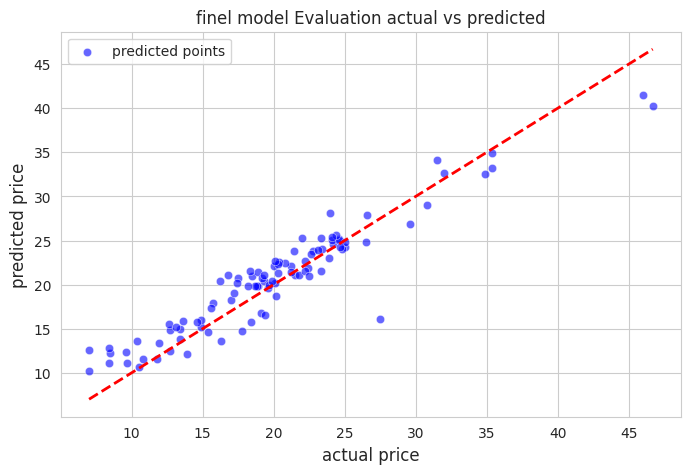

In [28]:
plt.figure(figsize=(8,5))
# scatter plot for actual vs predicted
sns.scatterplot(x=y_test,y=y_pred,alpha=0.6,color="blue",label="predicted points")
# perfect prediction line
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color="red",lw=2,linestyle="--",label="perfect prediction")
plt.xlabel("actual price",fontsize=12)
plt.ylabel("predicted price",fontsize=12)
plt.title("finel model Evaluation actual vs predicted",fontsize=12)
plt.legend
plt.grid(True)
plt.show()

#** final visual Evaluation **
** preformance** most bredicted points are tightly clustered around the 45-degree refrence line
**high Accuracy** this visual confirmation aligns with our 87% R2 score and 12% error rate
**Resulte** the random forest successful in capturing the underlying patterns of house pricing